# Notebook 02

## Phase 2 — Engineer & Transform Features

### Feature Engineering

Now that the data is clean, make it more useful for analysis. You will create new columns, convert categories to numbers, and rescale features.

---

## Tasks

> Create notebook: `02_features.ipynb`

- [ ] One-hot encode at least 2 categorical columns using `pd.get_dummies()`.
- [ ] Ordinal encode 1 ordered column (e.g., quality: low → high).
- [ ] Scale at least 2 numerical columns using `StandardScaler`.
- [ ] Create 2 domain features: a meaningful ratio (e.g., `price_per_sqft`) and one more of your choice. Use safe division to avoid dividing by zero.
- [ ] Create 1 interaction feature: multiply two columns that logically go together (e.g., quality × area).
- [ ] Log-transform 1 skewed column using `np.log1p()` — show the histogram before and after.
- [ ] Bin 1 column into meaningful groups (e.g., age groups: New, Recent, Old).
- [ ] Remove redundant features: find highly correlated pairs (r > 0.95) and drop one.

---

> **Tip:** For each new feature you create, write one sentence explaining why it might be useful.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data/cleaned/cleaned.csv")

In [3]:
# used in console: df.nunique()[df.nunique() < 5] to display columns with low unique values
df = pd.get_dummies(df, columns=["Land Slope", "Garage Finish"]) # one-hot encode categorical columns
# • One-hot encode at least 2 categorical columns using pd.get_dummies()

In [4]:
# used in console: df["Kitchen Qual"].value_counts() to display quality categories
order = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5} # map quality from poor → excellent (1 → 5)
df["Kitchen Qual"] = df["Kitchen Qual"].map(order) # # convert quality to numbers 1-5
# • Ordinal encode 1 ordered column (e.g., quality: low → high) -> poor → excellent mapped to 1 → 5

In [5]:
scaler = StandardScaler() # initialize standardScaler
cols = ["Lot Area", "Gr Liv Area"] # columns to scale
df[cols] = scaler.fit_transform(df[cols]) # fit and transform cols to mean=0, std=1
# • Scale at least 2 numerical columns using StandardScaler

In [6]:
df["price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, np.nan)  # price per square foot (safe division)
df["avg_room_size"] = df["Gr Liv Area"] / df["TotRms AbvGrd"].replace(0, np.nan)  # average room size (safe division)
# • Create 2 domain features: a meaningful ratio (e.g., price_per_sqft) and one more of your choice. Use safe division to avoid dividing by zero

In [7]:
df["qual_area_int"] = df["Overall Qual"] * df["Gr Liv Area"] # quality * area interaction
# • Create 1 interaction feature: multiply two columns that logically go together (e.g., quality × area)

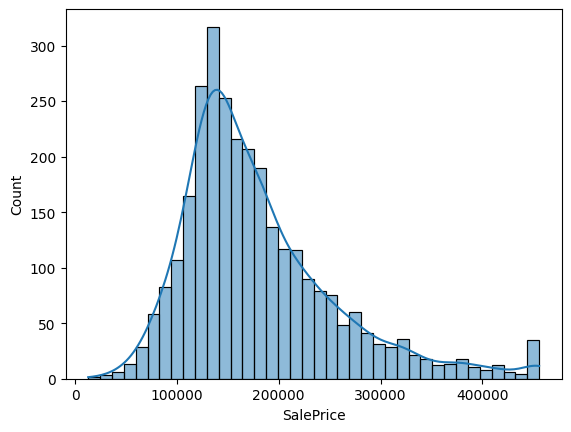

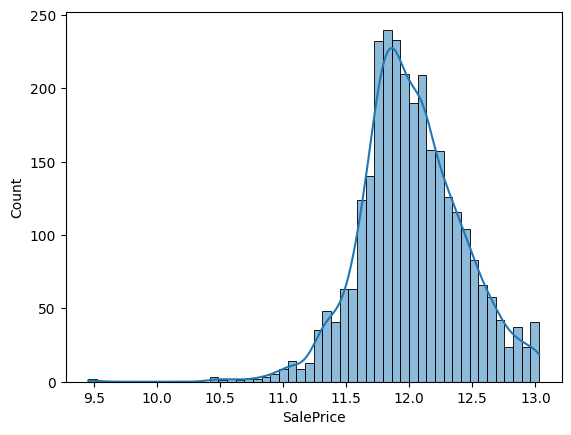

In [8]:
sns.histplot(df["SalePrice"], kde=True)
plt.show() # before log transform

df["SalePrice"] = np.log1p(df["SalePrice"]) # log transform to fix skew

sns.histplot(df["SalePrice"], kde=True)
plt.show() # after log transform
# • Log-transform 1 skewed column using np.log1p() — show the histogram before and after

In [9]:
bins = [0, 1950, 2000, 2025] # house age ranges: <1950, 1950–2000, 2000+
labels = ["Old", "Recent", "New"] # category labels

df["house_age_group"] = pd.cut(df["Year Built"], bins=bins, labels=labels) # bin year into age groups
# • Bin 1 column into meaningful groups (e.g., age groups: New, Recent, Old)

In [10]:
df_features = df.copy()
df_features.to_csv("data/processed/features.csv", index=False)